# XGBoost Classification of SDSS Objects

This notebook trains an **XGBoost** classifier on the same SDSS dataset used in
`sdss_analysis.ipynb` (Random Forest baseline). We compare the two models
side by side — accuracy, per-class metrics, confusion matrix, and feature importance.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

## 2. Load Data and Apply the Same Preprocessing

In [2]:
df = pd.read_csv('./dataset/star_classification.csv')
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Classes: {df['class'].value_counts().to_dict()}")

Dataset: 100000 rows, 18 columns
Classes: {'GALAXY': 59445, 'STAR': 21594, 'QSO': 18961}


In [3]:
# Same feature set and split as the original notebook
feature_columns = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z',
                   'run_ID', 'rerun_ID', 'cam_col', 'field_ID',
                   'redshift', 'plate', 'MJD', 'fiber_ID']

X = df[feature_columns]
y = df['class']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = list(label_encoder.classes_)
print(f"Class mapping: {dict(zip(class_names, range(len(class_names))))}")

# Train/test split — same random_state for a fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape[0]} | Test: {X_test_scaled.shape[0]}")

Class mapping: {'GALAXY': 0, 'QSO': 1, 'STAR': 2}
Train: 80000 | Test: 20000


## 3. Train XGBoost

In [14]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost test accuracy: {acc_xgb:.4f}")

XGBoost test accuracy: 0.9788


## 4. Train Random Forest (Baseline)

We re-train the same Random Forest from the original notebook so both models
are evaluated on the exact same split.

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest test accuracy: {acc_rf:.4f}")
print(f"XGBoost test accuracy:       {acc_xgb:.4f}")
print(f"Difference (XGB - RF):       {acc_xgb - acc_rf:+.4f}")

Random Forest test accuracy: 0.9761
XGBoost test accuracy:       0.9788
Difference (XGB - RF):       +0.0026


## 5. Classification Report — XGBoost

In [16]:
print("XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

XGBoost Classification Report:

              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.94      0.95      3792
        STAR       0.99      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



## 6. Cross-Validation

In [17]:
cv_xgb = cross_val_score(xgb_model, X_test_scaled, y_test, cv=5)
cv_rf = cross_val_score(rf_model, X_test_scaled, y_test, cv=5)

print(f"XGBoost  5-fold CV: {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}")
print(f"Random Forest CV:   {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

XGBoost  5-fold CV: 0.9772 ± 0.0017
Random Forest CV:   0.9739 ± 0.0026


## 7. Confusion Matrices — Side by Side

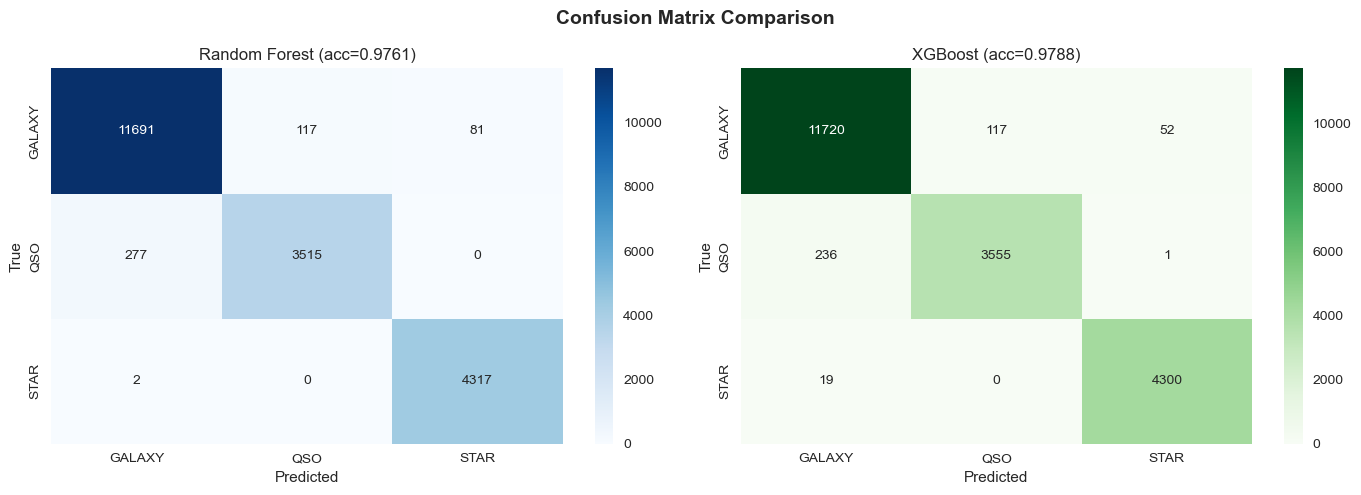

In [18]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title(f'Random Forest (acc={acc_rf:.4f})')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title(f'XGBoost (acc={acc_xgb:.4f})')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('docs/plots/xgb_vs_rf_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Per-Class Metric Comparison

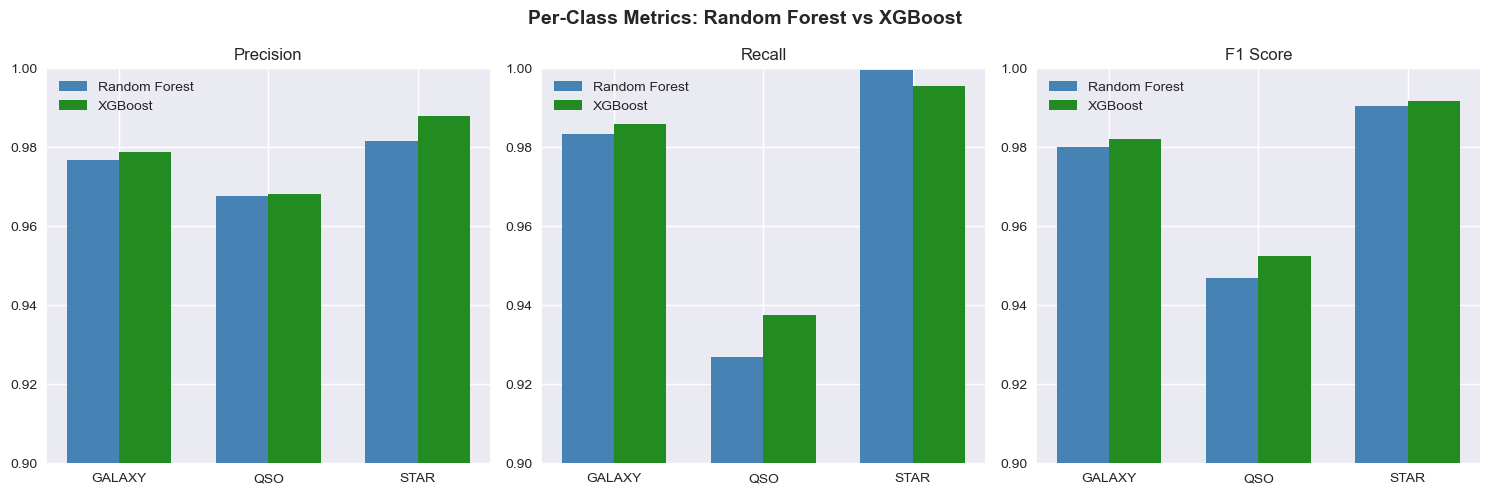

In [19]:
p_xgb, r_xgb, f1_xgb, _ = precision_recall_fscore_support(y_test, y_pred_xgb, average=None)
p_rf, r_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average=None)

x = np.arange(len(class_names))
w = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Precision
axes[0].bar(x - w/2, p_rf, w, label='Random Forest', color='steelblue')
axes[0].bar(x + w/2, p_xgb, w, label='XGBoost', color='forestgreen')
axes[0].set_xticks(x); axes[0].set_xticklabels(class_names)
axes[0].set_ylim(0.9, 1.0); axes[0].set_title('Precision'); axes[0].legend()

# Recall
axes[1].bar(x - w/2, r_rf, w, label='Random Forest', color='steelblue')
axes[1].bar(x + w/2, r_xgb, w, label='XGBoost', color='forestgreen')
axes[1].set_xticks(x); axes[1].set_xticklabels(class_names)
axes[1].set_ylim(0.9, 1.0); axes[1].set_title('Recall'); axes[1].legend()

# F1
axes[2].bar(x - w/2, f1_rf, w, label='Random Forest', color='steelblue')
axes[2].bar(x + w/2, f1_xgb, w, label='XGBoost', color='forestgreen')
axes[2].set_xticks(x); axes[2].set_xticklabels(class_names)
axes[2].set_ylim(0.9, 1.0); axes[2].set_title('F1 Score'); axes[2].legend()

plt.suptitle('Per-Class Metrics: Random Forest vs XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('docs/plots/xgb_vs_rf_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Importance Comparison

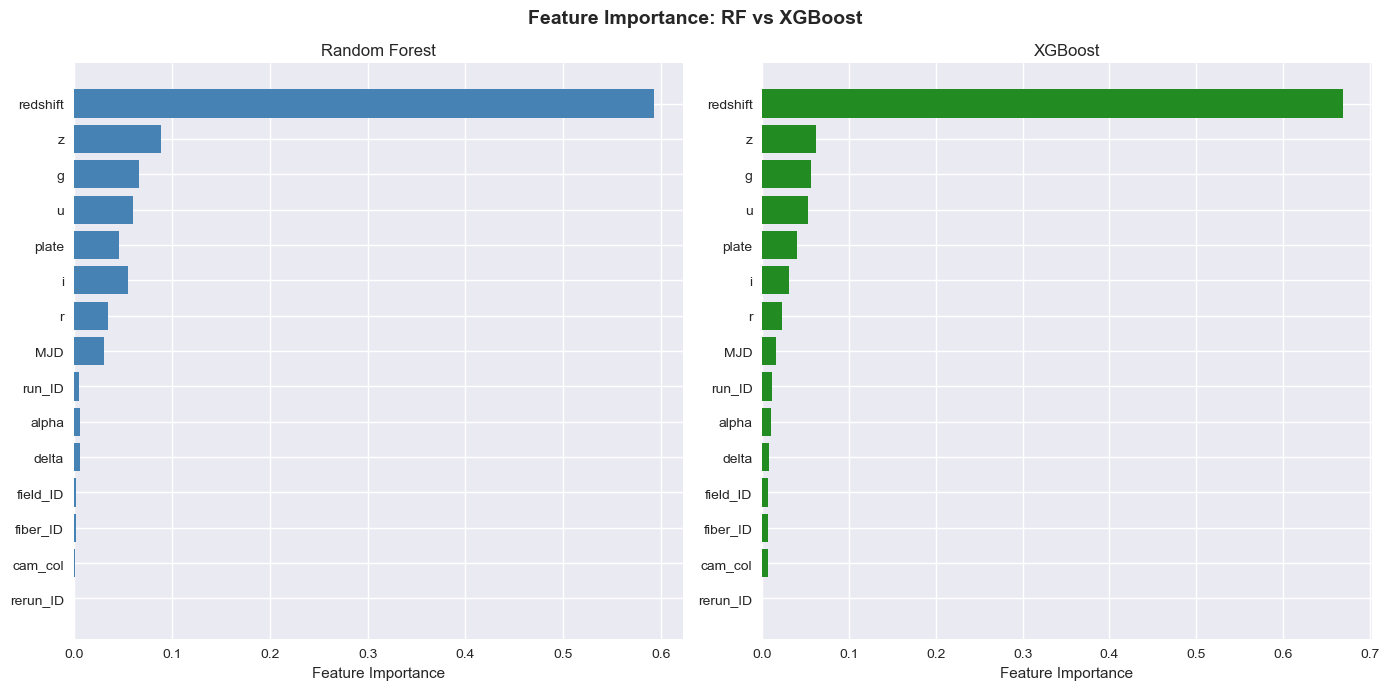

Top 5 features — Random Forest:
redshift    0.592827
z           0.089212
g           0.066862
u           0.060414
i           0.055577

Top 5 features — XGBoost:
redshift    0.668436
z           0.061583
g           0.056647
u           0.052360
plate       0.040334


In [20]:
imp_xgb = pd.Series(xgb_model.feature_importances_, index=feature_columns)
imp_rf = pd.Series(rf_model.feature_importances_, index=feature_columns)

# Sort by XGBoost importance
order = imp_xgb.sort_values(ascending=True).index

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(order, imp_rf[order], color='steelblue')
axes[0].set_title('Random Forest')
axes[0].set_xlabel('Feature Importance')

axes[1].barh(order, imp_xgb[order], color='forestgreen')
axes[1].set_title('XGBoost')
axes[1].set_xlabel('Feature Importance')

plt.suptitle('Feature Importance: RF vs XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('docs/plots/xgb_vs_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 5 from each
print("Top 5 features — Random Forest:")
print(imp_rf.sort_values(ascending=False).head().to_string())
print("\nTop 5 features — XGBoost:")
print(imp_xgb.sort_values(ascending=False).head().to_string())

## 10. Where Do the Models Disagree?

Look at test samples where one model is right and the other is wrong.

In [21]:
rf_correct = y_pred_rf == y_test
xgb_correct = y_pred_xgb == y_test

both_right = rf_correct & xgb_correct
both_wrong = ~rf_correct & ~xgb_correct
only_rf_right = rf_correct & ~xgb_correct
only_xgb_right = ~rf_correct & xgb_correct

print(f"Both correct:      {both_right.sum():>5}  ({both_right.sum()/len(y_test)*100:.1f}%)")
print(f"Both wrong:        {both_wrong.sum():>5}  ({both_wrong.sum()/len(y_test)*100:.1f}%)")
print(f"Only RF correct:   {only_rf_right.sum():>5}  ({only_rf_right.sum()/len(y_test)*100:.1f}%)")
print(f"Only XGB correct:  {only_xgb_right.sum():>5}  ({only_xgb_right.sum()/len(y_test)*100:.1f}%)")

Both correct:      19460  (97.3%)
Both wrong:          362  (1.8%)
Only RF correct:      63  (0.3%)
Only XGB correct:    115  (0.6%)


In [22]:
# What do the disagreement cases look like?
X_test_df = X_test.reset_index(drop=True)

# Cases where only XGBoost got it right
xgb_wins = X_test_df[only_xgb_right]
if len(xgb_wins) > 0:
    print(f"XGBoost-only correct cases ({len(xgb_wins)} rows):")
    print(f"  Mean redshift: {xgb_wins['redshift'].mean():.3f}")
    true_labels = label_encoder.inverse_transform(y_test[only_xgb_right])
    print(f"  True class distribution: {pd.Series(true_labels).value_counts().to_dict()}")

# Cases where only RF got it right
rf_wins = X_test_df[only_rf_right]
if len(rf_wins) > 0:
    print(f"\nRF-only correct cases ({len(rf_wins)} rows):")
    print(f"  Mean redshift: {rf_wins['redshift'].mean():.3f}")
    true_labels = label_encoder.inverse_transform(y_test[only_rf_right])
    print(f"  True class distribution: {pd.Series(true_labels).value_counts().to_dict()}")

XGBoost-only correct cases (115 rows):
  Mean redshift: 0.525
  True class distribution: {'GALAXY': 63, 'QSO': 50, 'STAR': 2}

RF-only correct cases (63 rows):
  Mean redshift: 0.425
  True class distribution: {'GALAXY': 34, 'STAR': 19, 'QSO': 10}


## 11. Summary Table

In [23]:
summary = pd.DataFrame({
    'Metric': ['Test Accuracy', '5-Fold CV Mean', 'CV Std Dev',
               'GALAXY F1', 'QSO F1', 'STAR F1', 'Macro F1'],
    'Random Forest': [
        f"{acc_rf:.4f}",
        f"{cv_rf.mean():.4f}",
        f"{cv_rf.std():.4f}",
        f"{f1_rf[0]:.4f}",
        f"{f1_rf[1]:.4f}",
        f"{f1_rf[2]:.4f}",
        f"{f1_rf.mean():.4f}",
    ],
    'XGBoost': [
        f"{acc_xgb:.4f}",
        f"{cv_xgb.mean():.4f}",
        f"{cv_xgb.std():.4f}",
        f"{f1_xgb[0]:.4f}",
        f"{f1_xgb[1]:.4f}",
        f"{f1_xgb[2]:.4f}",
        f"{f1_xgb.mean():.4f}",
    ]
})

print(summary.to_string(index=False))

        Metric Random Forest XGBoost
 Test Accuracy        0.9761  0.9788
5-Fold CV Mean        0.9739  0.9772
    CV Std Dev        0.0026  0.0017
     GALAXY F1        0.9800  0.9822
        QSO F1        0.9469  0.9526
       STAR F1        0.9905  0.9917
      Macro F1        0.9725  0.9755


## Takeaways

- **XGBoost** builds trees sequentially (each corrects the errors of the last),
  while **Random Forest** builds them independently and averages.
- On this dataset, both perform well because **redshift alone** is already
  highly predictive (~60% of RF's importance). The remaining gains come from
  resolving the QSO/GALAXY overlap in colour–redshift space.
- The "disagree" analysis (§10) shows where boosting picks up patterns that
  bagging misses — typically the harder boundary cases.
